In [7]:
#all libraries needed
import pandas as pd
import numpy as np

import sys 
!{sys.executable} -m pip install xgboost
from pathlib import Path
import seaborn as sns
import matplotlib.pyplot as plt
import datetime as datetime
import xgboost as xgb
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score

from sklearn.linear_model import LogisticRegression 
from sklearn.ensemble import RandomForestClassifier 
from xgboost import XGBClassifier



Defaulting to user installation because normal site-packages is not writeable


In [9]:
#patrick martin section
# Load the parquet file
df = pd.read_parquet("MarketData_2022-2026.parquet")

# Save as CSV
df.to_csv("MarketData_2022-2026.csv", index=False)

DATA_PATH = Path("MarketData_2022-2026.csv")
df = pd.read_csv("MarketData_2022-2026.csv")
DT_COL = "StartDateTime"
df['StartDateTime'] = pd.to_datetime(
    df['StartDateTime'],
    errors="coerce",
    utc=True
)



df['Time'] = df['StartDateTime'].dt.time

# Create TradeDate variable. Each trade date starts at 23:00 and ends at 22:30.
df['TradeDate'] = np.where(df['Time'] < datetime.time(23,0), df['StartDateTime'].dt.date, df['StartDateTime'].dt.date + datetime.timedelta(days=1))
df['TradeDate']

before = len(df)
df = df.dropna(subset=[DT_COL]).sort_values(DT_COL).reset_index(drop=True)
print("Dropped invalid datetime rows:", before - len(df))

Dropped invalid datetime rows: 0


In [10]:
#patrick martin section
missing_per_column = df.isna().sum()

# Total number of missing values in the entire dataset
total_missing = df.isna().sum().sum()

print("Missing values per column:")
print(missing_per_column)

print("\nTotal missing values:", total_missing)
total_missing_pct = df.isna().sum().sum() / df.size * 100 
print("\nTotal missing percentage:", total_missing_pct)


Missing values per column:
StartDateTime              0
EirgridActualDemand       33
Meteo_ISEMWIND_DAM         0
Meteo_ISEMWIND_IDA1      184
Meteo_ISEMWIND_IDA2    36537
                       ...  
NI_GB_MW                 622
GB2_IE2_MW               622
IE2_GB2_MW               622
Time                       0
TradeDate                  0
Length: 104, dtype: int64

Total missing values: 2060359

Total missing percentage: 27.15901601311842


In [11]:
#Dam ->  Bam market setup 
PRICE_EARLY = "PriceDAM"  
PRICE_LATE  = "PriceImbalance"  


# Standardise column names (optional but recommended)
#    - strips whitespace
#    - replaces spaces with underscores

df.columns = (
    df.columns
    .astype(str)
    .str.strip()
    .str.replace(" ", "_", regex=False)
)
df 


#Remove duplicate time periods 
before = len(df)
df = df.drop_duplicates(subset=[DT_COL], keep="first")
print("Removed duplicate timestamps:", before - len(df))


#Convert numeric-like columns safely
def to_numeric_safe(s: pd.Series) -> pd.Series:
    if pd.api.types.is_numeric_dtype(s):
        return s
    if pd.api.types.is_datetime64_any_dtype(s):
        return s
    if s.dtype == "object":
        cleaned = s.astype(str).str.replace(",", "", regex=False).str.strip()
        return pd.to_numeric(cleaned, errors="ignore")  # keep non-numeric as-is
    return s

df = df.apply(to_numeric_safe)


#Drop rows missing key prices 
before = len(df)
df = df.dropna(subset=[PRICE_EARLY, PRICE_LATE])
print("Dropped rows missing key prices:", before - len(df))


# Create target variables (spread + direction)
df["spread"] = df[PRICE_LATE] - df[PRICE_EARLY]
df["y_dir"] = np.where(df["spread"] > 0, 1, -1)

print("Spread summary:")
print(df["spread"].describe())


if {"EirGridDemandFc_DAM", "EirGridWindFc_DAM"}.issubset(df.columns):
    if "ISEMSOLAR_DAM" in df.columns:
        df["net_demand_fc_DAM"] = df["EirGridDemandFc_DAM"] - df["EirGridWindFc_DAM"] - df["ISEMSOLAR_DAM"]
    else:
        df["net_demand_fc_DAM"] = df["EirGridDemandFc_DAM"] - df["EirGridWindFc_DAM"]

if {"ISEMWINDP90_DAM", "ISEMWINDP10_DAM"}.issubset(df.columns):
    df["wind_uncertainty_DAM"] = df["ISEMWINDP90_DAM"] - df["ISEMWINDP10_DAM"]


OUT_PATH = Path("MarketData_clean.csv")
df.to_csv(OUT_PATH, index=False)
print(f"Saved cleaned file: {OUT_PATH.resolve()}")


Removed duplicate timestamps: 2865
Dropped rows missing key prices: 17
Spread summary:
count    70063.000000
mean        -1.573013
std         74.903161
min       -641.380000
25%        -49.330000
50%        -10.210000
75%         44.365000
max        465.130000
Name: spread, dtype: float64


C:\Users\40337868\AppData\Local\Temp\ipykernel_5492\119857082.py:33: FutureWarning: errors='ignore' is deprecated and will raise in a future version. Use to_numeric without passing `errors` and catch exceptions explicitly instead
  return pd.to_numeric(cleaned, errors="ignore")  # keep non-numeric as-is
C:\Users\40337868\AppData\Local\Temp\ipykernel_5492\119857082.py:33: FutureWarning: errors='ignore' is deprecated and will raise in a future version. Use to_numeric without passing `errors` and catch exceptions explicitly instead
  return pd.to_numeric(cleaned, errors="ignore")  # keep non-numeric as-is


Saved cleaned file: C:\Users\40337868\Downloads\MarketData_clean.csv


In [12]:
print(df.columns.tolist())

['StartDateTime', 'EirgridActualDemand', 'Meteo_ISEMWIND_DAM', 'Meteo_ISEMWIND_IDA1', 'Meteo_ISEMWIND_IDA2', 'Meteo_ISEMWIND_IDA3', 'EirgridActualWind', 'Meteo_ISEMDEMAND_DAM', 'Meteo_ISEMDEMAND_IDA1', 'Meteo_ISEMDEMAND_IDA2', 'Meteo_ISEMDEMAND_IDA3', 'PriceDAM', 'PriceIDA1', 'PriceIDA2', 'PriceIDA3', 'PriceImbalance', 'LoadForecastROI', 'LoadForecastNI', 'AggregatedForecast', 'PumpStorage', 'LTS_IC_NI', 'LTS_IC_ROI', 'TotalPN', 'LTS_IC_NI_DAM', 'LTS_IC_NI_IDA1', 'LTS_IC_NI_IDA2', 'LTS_IC_NI_IDA3', 'LTS_IC_ROI_DAM', 'LTS_IC_ROI_IDA1', 'LTS_IC_ROI_IDA2', 'LTS_IC_ROI_IDA3', 'PN_IDA1', 'PN_IDA2', 'PN_IDA3', 'ActualMeterData', 'EirGridDemandFc_DAM', 'EirGridDemandFc_IDA1', 'EirGridDemandFc_IDA2', 'EirGridDemandFc_IDA3', 'EirGridWindFc_DAM', 'EirGridWindFc_IDA1', 'EirGridWindFc_IDA2', 'EirGridWindFc_IDA3', 'EmSys_C_ISEMWIND_DAM', 'EmSys_C_ISEMWIND_IDA1', 'EmSys_C_ISEMWIND_IDA2', 'EmSys_C_ISEMWIND_IDA3', 'EmSys_U_ISEMWIND_DAM', 'EmSys_U_ISEMWIND_IDA1', 'EmSys_U_ISEMWIND_IDA2', 'EmSys_U_ISEMW

In [13]:
#patrick martin section
#A look at the spread and y_dir values
df[["StartDateTime", PRICE_EARLY, PRICE_LATE, "spread", "y_dir"]].head()


,StartDateTime,PriceDAM,PriceImbalance,spread,y_dir
0,2022-01-01 23:00:00+00:00,78.91,0.0,-78.91,-1
1,2022-01-01 23:30:00+00:00,78.91,0.0,-78.91,-1
2,2022-01-02 00:00:00+00:00,60.00,0.0,-60.00,-1
3,2022-01-02 00:30:00+00:00,60.00,0.0,-60.00,-1
4,2022-01-02 01:00:00+00:00,43.73,0.0,-43.73,-1


In [14]:
#Quintin Quinn section
dam_features = [
    "Meteo_ISEMDEMAND_DAM",
    "EirGridDemandFc_DAM",
    "ISEMDEMAND_DAM",
    "ISEMWIND_U_M_50_DAM",
    "Meteo_ISEMWIND_DAM",
    "EirGridWindFc_DAM",
    "ISEMWINDP10_DAM",
    "LoadForecastROI",
    "LoadForecastNI",
    "AggregatedForecast",
    "ISEMWINDP90_DAM",
    "PriceDAM",
    "GB_DAM_N2EX",
    "GB_DAM_Epex",
]
missing_counts = df[dam_features].isna().sum()
print(missing_counts)


Meteo_ISEMDEMAND_DAM        0
EirGridDemandFc_DAM         0
ISEMDEMAND_DAM              0
ISEMWIND_U_M_50_DAM     24725
Meteo_ISEMWIND_DAM          0
EirGridWindFc_DAM          46
ISEMWINDP10_DAM             0
LoadForecastROI            11
LoadForecastNI             11
AggregatedForecast         11
ISEMWINDP90_DAM             0
PriceDAM                    0
GB_DAM_N2EX                 0
GB_DAM_Epex                 0
dtype: int64


Number of DAM features: 13
['Meteo_ISEMDEMAND_DAM', 'EirGridDemandFc_DAM', 'ISEMDEMAND_DAM', 'Meteo_ISEMWIND_DAM', 'EirGridWindFc_DAM', 'ISEMWINDP10_DAM', 'LoadForecastROI', 'LoadForecastNI', 'AggregatedForecast', 'ISEMWINDP90_DAM', 'PriceDAM', 'GB_DAM_N2EX', 'GB_DAM_Epex']


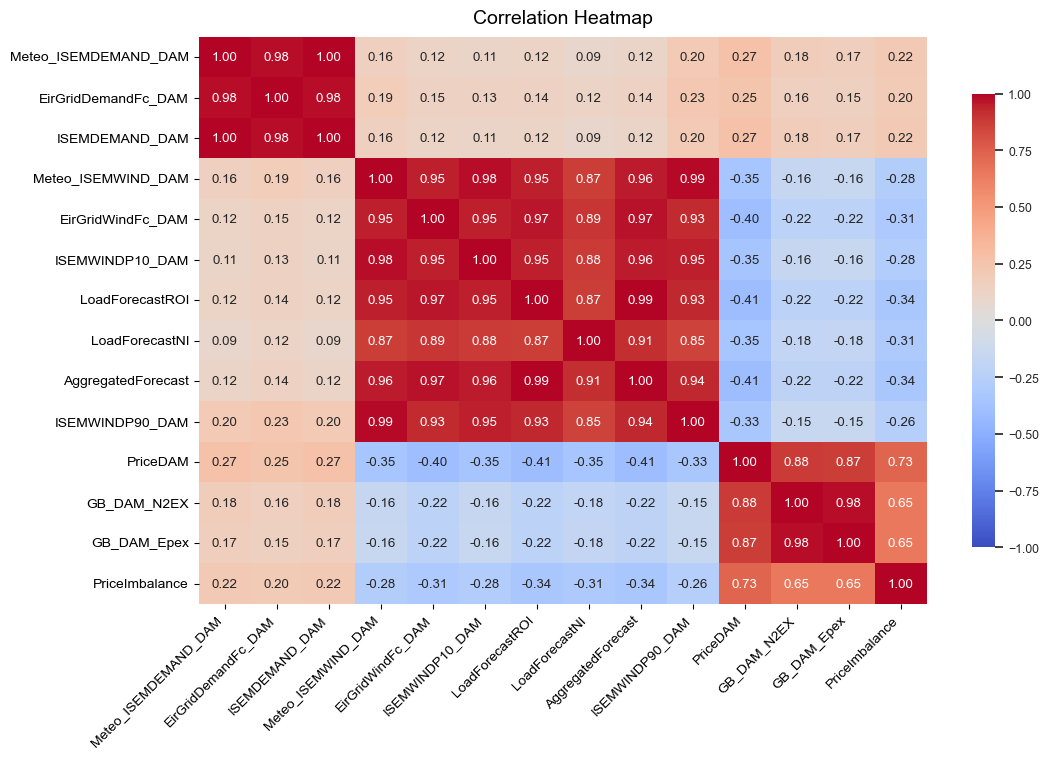

In [15]:
#Quintin Quinn section
#all features we have access to at dam market along with spread and PriceImbalance
dam_features = [c for c in dam_features if c != "ISEMWIND_U_M_50_DAM"]


print("Number of DAM features:", len(dam_features))
print(dam_features)


# Create correlation dataframe
heatmap_features = dam_features + [ "PriceImbalance"]

corr_df = df[heatmap_features].select_dtypes(include="number")



fig, ax = plt.subplots(figsize=(13, 9))
sns.set(font_scale=0.8)  # slightly smaller fonts

heatmap = sns.heatmap(
    corr_df.corr(),
    vmin=-1,
    vmax=1,
    cmap="coolwarm",
    annot=True,
    fmt=".2f",
    square=False,              
    cbar_kws={"shrink": 0.8},
    ax=ax
)

ax.set_title("Correlation Heatmap", fontsize=14, pad=10)

# rotate and align tick labels
ax.set_xticklabels(
    ax.get_xticklabels(),
    rotation=45,
    ha="right"
)
ax.set_yticklabels(
    ax.get_yticklabels(),
    rotation=0,  # often easier to read
    va="center"
)

# give extra room for x labels
fig.subplots_adjust(bottom=0.25, left=0.2)

plt.show()



In [16]:
model_df = df[["StartDateTime", "spread", "y_dir"] + dam_features].copy()
print("Model df shape:", model_df.shape)
model_df.head()


Model df shape: (70063, 16)


,StartDateTime,spread,y_dir,Meteo_ISEMDEMAND_DAM,EirGridDemandFc_DAM,ISEMDEMAND_DAM,Meteo_ISEMWIND_DAM,EirGridWindFc_DAM,ISEMWINDP10_DAM,LoadForecastROI,LoadForecastNI,AggregatedForecast,ISEMWINDP90_DAM,PriceDAM,GB_DAM_N2EX,GB_DAM_Epex
0,2022-01-01 23:00:00+00:00,-78.91,-1,3736.0,3928.0,3736.0,2636.0,2877.930,2192.0,2258.050,639.430,2897.480,3246.0,78.91,104.222910,81.39994
1,2022-01-01 23:30:00+00:00,-78.91,-1,3632.0,3878.0,3632.0,2588.0,2860.431,2151.0,2257.777,620.336,2878.113,3179.0,78.91,104.222910,81.39994
2,2022-01-02 00:00:00+00:00,-60.00,-1,3508.0,3752.0,3508.0,2573.0,2842.940,2149.0,2257.499,601.247,2858.746,3143.0,60.00,55.525962,61.37770
3,2022-01-02 00:30:00+00:00,-60.00,-1,3379.0,3617.0,3379.0,2592.0,2866.127,2186.0,2273.307,598.977,2872.284,3136.0,60.00,55.525962,61.37770
4,2022-01-02 01:00:00+00:00,-43.73,-1,3254.0,3497.0,3254.0,2594.0,2889.315,2210.0,2397.676,615.707,3013.383,3112.0,43.73,38.733500,39.56776


In [17]:
na_counts = model_df[dam_features].isna().sum().sort_values(ascending=False)
print("Top missing feature counts:")
print(na_counts.head(15))

print("\nTotal missing values in selected features:", int(model_df[dam_features].isna().sum().sum()))

# Check dtypes for all DAM features
print(df[dam_features].dtypes)





Top missing feature counts:
EirGridWindFc_DAM       46
LoadForecastROI         11
LoadForecastNI          11
AggregatedForecast      11
Meteo_ISEMDEMAND_DAM     0
EirGridDemandFc_DAM      0
ISEMDEMAND_DAM           0
Meteo_ISEMWIND_DAM       0
ISEMWINDP10_DAM          0
ISEMWINDP90_DAM          0
PriceDAM                 0
GB_DAM_N2EX              0
GB_DAM_Epex              0
dtype: int64

Total missing values in selected features: 79
Meteo_ISEMDEMAND_DAM    float64
EirGridDemandFc_DAM     float64
ISEMDEMAND_DAM          float64
Meteo_ISEMWIND_DAM      float64
EirGridWindFc_DAM       float64
ISEMWINDP10_DAM         float64
LoadForecastROI         float64
LoadForecastNI          float64
AggregatedForecast      float64
ISEMWINDP90_DAM         float64
PriceDAM                float64
GB_DAM_N2EX             float64
GB_DAM_Epex             float64
dtype: object


In [18]:
#Patrick Martin  section
# Make sure model_df has no missing values in the columns you use
# model_df = model_df.dropna(subset=dam_features + ["y_dir", "spread"])
from sklearn.impute import SimpleImputer


#spilt so our test set is over a single year
train = model_df[model_df["StartDateTime"] < "2025-01-01"]
test  = model_df[model_df["StartDateTime"] >= "2025-01-01"]


print("Train rows:", len(train), "Test rows:", len(test))
print("Train date range:", train["StartDateTime"].min(), "to", train["StartDateTime"].max())
print("Test  date range:", test["StartDateTime"].min(),  "to", test["StartDateTime"].max())



#Feature + Target Setup

dam_features = [c for c in dam_features if c in model_df.columns]

X_train = train[dam_features].copy()
y_train = train["y_dir"].copy()

X_test  = test[dam_features].copy()
y_test  = test["y_dir"].copy()


imputer = SimpleImputer(strategy="median")

X_train = pd.DataFrame(imputer.fit_transform(X_train), columns=X_train.columns, index=X_train.index)
X_test  = pd.DataFrame(imputer.transform(X_test), columns=X_test.columns, index=X_test.index)

print("NaNs in X_train:", int(X_train.isna().sum().sum()))
print("NaNs in X_test :", int(X_test.isna().sum().sum()))

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train value counts:")
print(y_train.value_counts())


Train rows: 52547 Test rows: 17516
Train date range: 2022-01-01 23:00:00+00:00 to 2024-12-31 23:30:00+00:00
Test  date range: 2025-01-01 00:00:00+00:00 to 2025-12-31 22:30:00+00:00
NaNs in X_train: 0
NaNs in X_test : 0
X_train shape: (52547, 13)
X_test shape: (17516, 13)
y_train value counts:
y_dir
-1    28651
 1    23896
Name: count, dtype: int64


In [19]:
#Quintin Quinn section
#################
#The basic models without threshold restirctions 
# dam -> bam first
#dam -> ida1
#then plot comparisions

In [20]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)


In [21]:
#patrick MArtin block
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier


# Logistic Regression 

logit = LogisticRegression(
    max_iter=1000,
    class_weight="balanced",
    random_state=42
)
logit.fit(X_train_scaled, y_train)


#Random Forest 

rf = RandomForestClassifier(
    n_estimators=300,
    max_depth=8,
    min_samples_leaf=50,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)
rf.fit(X_train, y_train)


# XGBoost

y_train_xgb = (y_train == 1).astype(int)

####

#  XGBoost is very nuetral with predicitng -/+1 but, we going to Predict longs more aggressively, because they are rarer and more profitable. 
#####
pos_weight = (y_train_xgb == 0).sum() / (y_train_xgb == 1).sum() 
print("scale_pos_weight =", pos_weight)

xgb = XGBClassifier(
    n_estimators=300,
    max_depth=5,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="binary:logistic",
    eval_metric="logloss",
    scale_pos_weight=pos_weight,  
    random_state=42
)

xgb.fit(X_train, y_train_xgb)


scale_pos_weight = 1.1989872782055575


XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.8, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.05, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=5, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=300, n_jobs=None,
              num_parallel_tree=None, ...)

In [22]:
#Patrick Martin section
# models beofre  threshold restirction from DAM -> BM

# Logistic Regression 

logit = LogisticRegression(
    max_iter=1000,
    class_weight="balanced",
    random_state=42
)
logit.fit(X_train_scaled, y_train)

# Random Forest 

rf = RandomForestClassifier(
    n_estimators=300,
    max_depth=8,
    min_samples_leaf=50,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)
rf.fit(X_train, y_train)

# XGBoost 
y_train_xgb = (y_train == 1).astype(int)

# Handle class imbalance
pos_weight = (y_train_xgb == 0).sum() / (y_train_xgb == 1).sum()
print("scale_pos_weight =", pos_weight)

xgb = XGBClassifier(
    n_estimators=300,
    max_depth=5,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="binary:logistic",
    eval_metric="logloss",
    scale_pos_weight=pos_weight,
    random_state=42
)

xgb.fit(X_train, y_train_xgb)

# Probabilities 
logit_test_prob = logit.predict_proba(X_test_scaled)[:,1]
rf_test_prob    = rf.predict_proba(X_test)[:,1]
xgb_test_prob   = xgb.predict_proba(X_test)[:,1]


# Probabilities (TRAIN)
logit_train_prob = logit.predict_proba(X_train_scaled)[:,1]
rf_train_prob    = rf.predict_proba(X_train)[:,1]
xgb_train_prob   = xgb.predict_proba(X_train)[:,1]


#  FUNCTION: Evaluate executed trades




def evaluate_exec_trades(model_name, exec_dir, y_true, spread):
    mask = exec_dir != 0  # only evaluate trades actually taken
    
    y_pred = exec_dir[mask]
    y_t = y_true.loc[mask] if hasattr(y_true, "loc") else y_true[mask]
    sp = spread.loc[mask] if hasattr(spread, "loc") else spread[mask]

    pnl = y_pred * sp

 # --- Accuracy ---
    acc = accuracy_score(y_t, y_pred)

    print(f"\n===== {model_name} =====")
    print("Trades:", int(mask.sum()))
    print("Accuracy:", round(acc, 3))
    print("Total P&L:", round(pnl.sum(), 2))
    print("€/MWh:", round(pnl.sum() / mask.sum(), 3))
    print("Win rate:", round((pnl > 0).mean(), 3))

    if (pnl < 0).any():
        pf = pnl[pnl > 0].sum() / abs(pnl[pnl < 0].sum())
    else:
        pf = float("inf")
    print("Profit factor:", round(pf, 3))



#  NEW: Evaluate models  thresholding


raw_logit_dir = np.where(logit_test_prob >= 0.5, 1, -1)
raw_rf_dir    = np.where(rf_test_prob >= 0.5, 1, -1)
raw_xgb_dir   = np.where(xgb_test_prob >= 0.5, 1, -1)

print("\n===== RAW MODEL PERFORMANCE (NO THRESHOLD) =====")
evaluate_exec_trades("Logit (Raw)", raw_logit_dir, y_test, test["spread"])
evaluate_exec_trades("RF (Raw)", raw_rf_dir, y_test, test["spread"])
evaluate_exec_trades("XGB (Raw)", raw_xgb_dir, y_test, test["spread"])





scale_pos_weight = 1.1989872782055575

===== RAW MODEL PERFORMANCE (NO THRESHOLD) =====

===== Logit (Raw) =====
Trades: 17516
Accuracy: 0.549
Total P&L: 106471.54
€/MWh: 6.079
Win rate: 0.544
Profit factor: 1.202

===== RF (Raw) =====
Trades: 17516
Accuracy: 0.555
Total P&L: 63245.14
€/MWh: 3.611
Win rate: 0.55
Profit factor: 1.115

===== XGB (Raw) =====
Trades: 17516
Accuracy: 0.557
Total P&L: 96898.0
€/MWh: 5.532
Win rate: 0.551
Profit factor: 1.182


In [23]:
#Quintin Quinn Section
############## comparing from DAM -> IDA1

PRICE_LATE_IDA = "PriceIDA1"


# Spread + direction
df["spread_ida"] = df[PRICE_LATE_IDA] - df[PRICE_EARLY]
df["y_dir_ida"] = np.where(df["spread_ida"] > 0, 1, -1)

print(df["spread_ida"].describe())

# Model dataframe
model_df_ida = df[["StartDateTime", "spread_ida", "y_dir_ida"] + dam_features].copy()

# Train/test split
train_ida = model_df_ida[model_df_ida["StartDateTime"] < "2025-01-01"]
test_ida  = model_df_ida[model_df_ida["StartDateTime"] >= "2025-01-01"]


# Features + targets
dam_features_ida = [c for c in dam_features if c in model_df_ida.columns]

X_train_ida = train_ida[dam_features_ida].copy()
y_train_ida = train_ida["y_dir_ida"].copy()

X_test_ida  = test_ida[dam_features_ida].copy()
y_test_ida  = test_ida["y_dir_ida"].copy()

# Impute
imputer_ida = SimpleImputer(strategy="median")
X_train_ida = pd.DataFrame(imputer_ida.fit_transform(X_train_ida), columns=X_train_ida.columns, index=X_train_ida.index)
X_test_ida  = pd.DataFrame(imputer_ida.transform(X_test_ida), columns=X_test_ida.columns, index=X_test_ida.index)

# Scale for logistic regression
scaler_ida = StandardScaler()
X_train_scaled_ida = scaler_ida.fit_transform(X_train_ida)
X_test_scaled_ida  = scaler_ida.transform(X_test_ida)


# Logistic Regression

logit_ida = LogisticRegression(
    max_iter=1000,
    class_weight="balanced",
    random_state=42
)
logit_ida.fit(X_train_scaled_ida, y_train_ida)


# Random Forest

rf_ida = RandomForestClassifier(
    n_estimators=300,
    max_depth=8,
    min_samples_leaf=50,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)
rf_ida.fit(X_train_ida, y_train_ida)


# XGBoost

y_train_xgb_ida = (y_train_ida == 1).astype(int)
pos_weight_ida = (y_train_xgb_ida == 0).sum() / (y_train_xgb_ida == 1).sum()

xgb_ida = XGBClassifier(
    n_estimators=300,
    max_depth=5,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="binary:logistic",
    eval_metric="logloss",
    scale_pos_weight=pos_weight_ida,
    random_state=42
)
xgb_ida.fit(X_train_ida, y_train_xgb_ida)

# Probabilities (TEST)

logit_test_prob_ida = logit_ida.predict_proba(X_test_scaled_ida)[:,1]
rf_test_prob_ida    = rf_ida.predict_proba(X_test_ida)[:,1]
xgb_test_prob_ida   = xgb_ida.predict_proba(X_test_ida)[:,1]


# Raw trade directions

raw_logit_dir_ida = np.where(logit_test_prob_ida >= 0.5, 1, -1)
raw_rf_dir_ida    = np.where(rf_test_prob_ida >= 0.5, 1, -1)
raw_xgb_dir_ida   = np.where(xgb_test_prob_ida >= 0.5, 1, -1)


# Evaluate raw models

print("\n===== RAW MODEL PERFORMANCE (IDA1) =====")
evaluate_exec_trades("Logit (Raw IDA)", raw_logit_dir_ida, y_test_ida, test_ida["spread_ida"])
evaluate_exec_trades("RF (Raw IDA)",    raw_rf_dir_ida,    y_test_ida, test_ida["spread_ida"])
evaluate_exec_trades("XGB (Raw IDA)",   raw_xgb_dir_ida,   y_test_ida, test_ida["spread_ida"])



count    70063.000000
mean        -1.631240
std         22.855468
min       -337.640000
25%        -11.050000
50%         -1.370000
75%          7.640000
max        217.000000
Name: spread_ida, dtype: float64

===== RAW MODEL PERFORMANCE (IDA1) =====

===== Logit (Raw IDA) =====
Trades: 17516
Accuracy: 0.557
Total P&L: 49552.53
€/MWh: 2.829
Win rate: 0.551
Profit factor: 1.491

===== RF (Raw IDA) =====
Trades: 17516
Accuracy: 0.575
Total P&L: 22700.97
€/MWh: 1.296
Win rate: 0.568
Profit factor: 1.198

===== XGB (Raw IDA) =====
Trades: 17516
Accuracy: 0.573
Total P&L: 47065.85
€/MWh: 2.687
Win rate: 0.566
Profit factor: 1.46


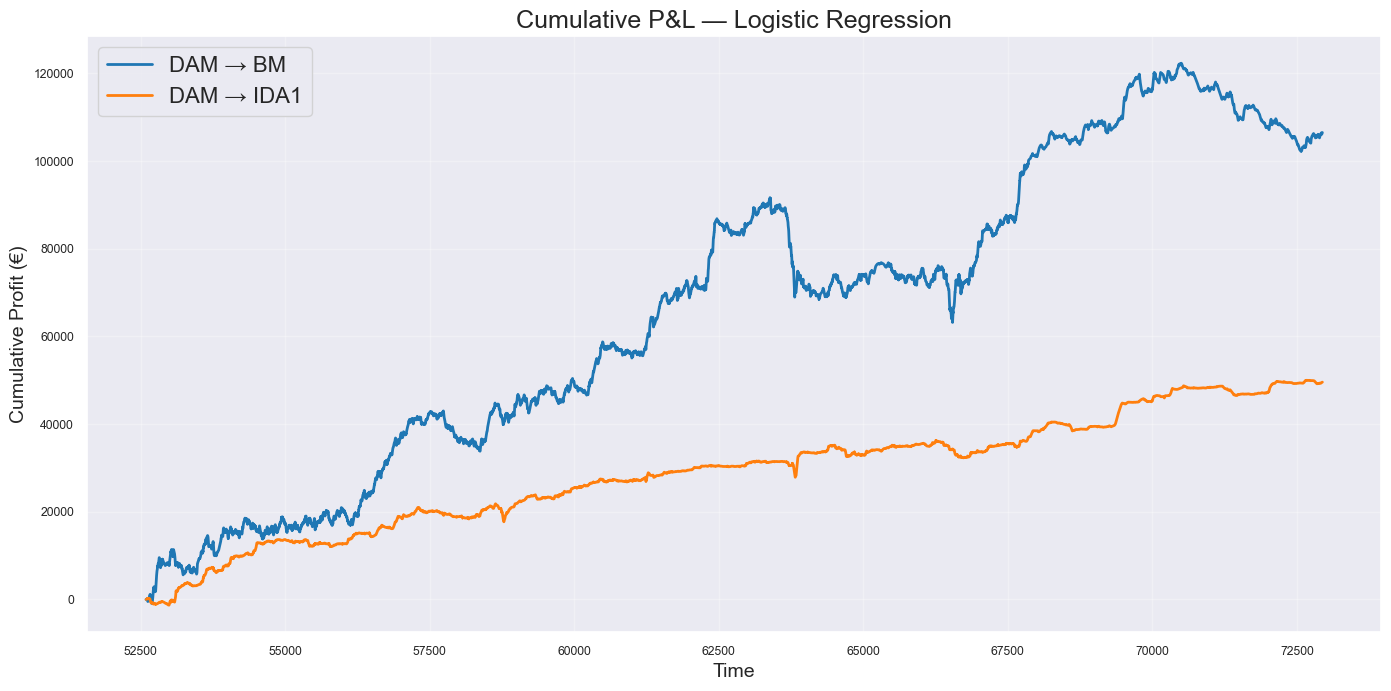

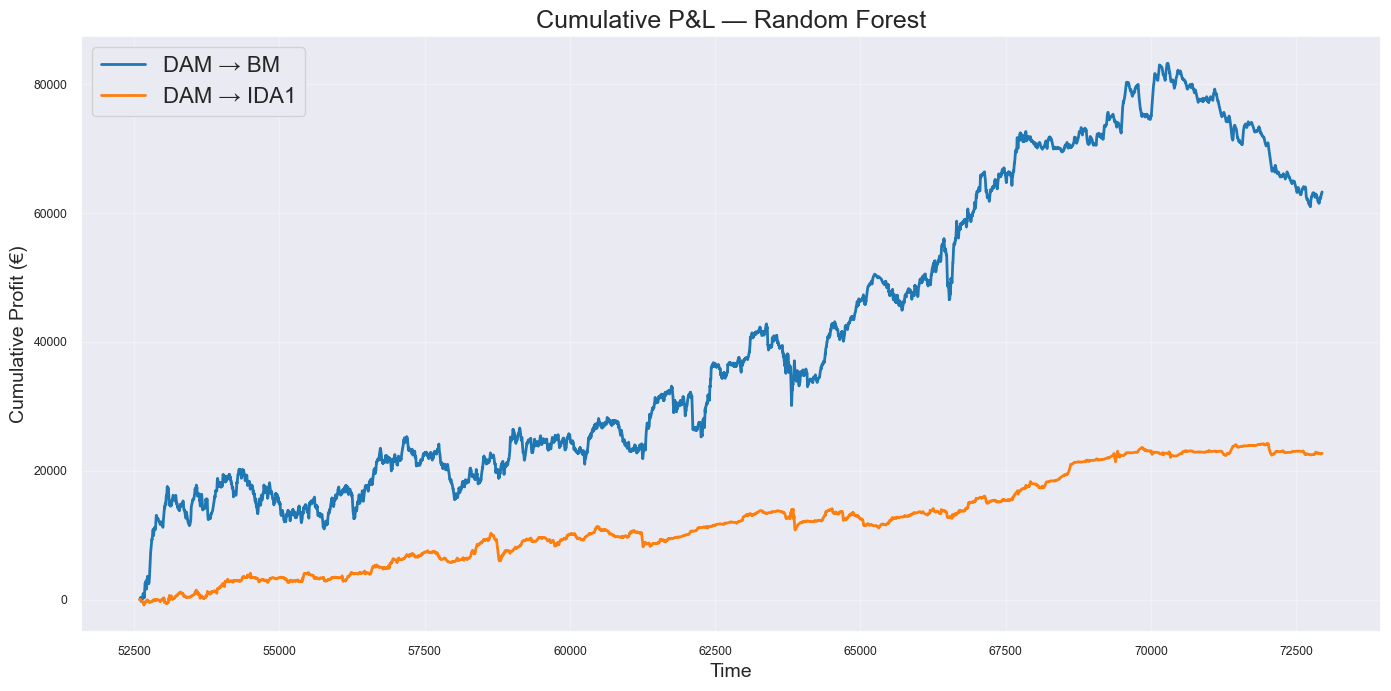

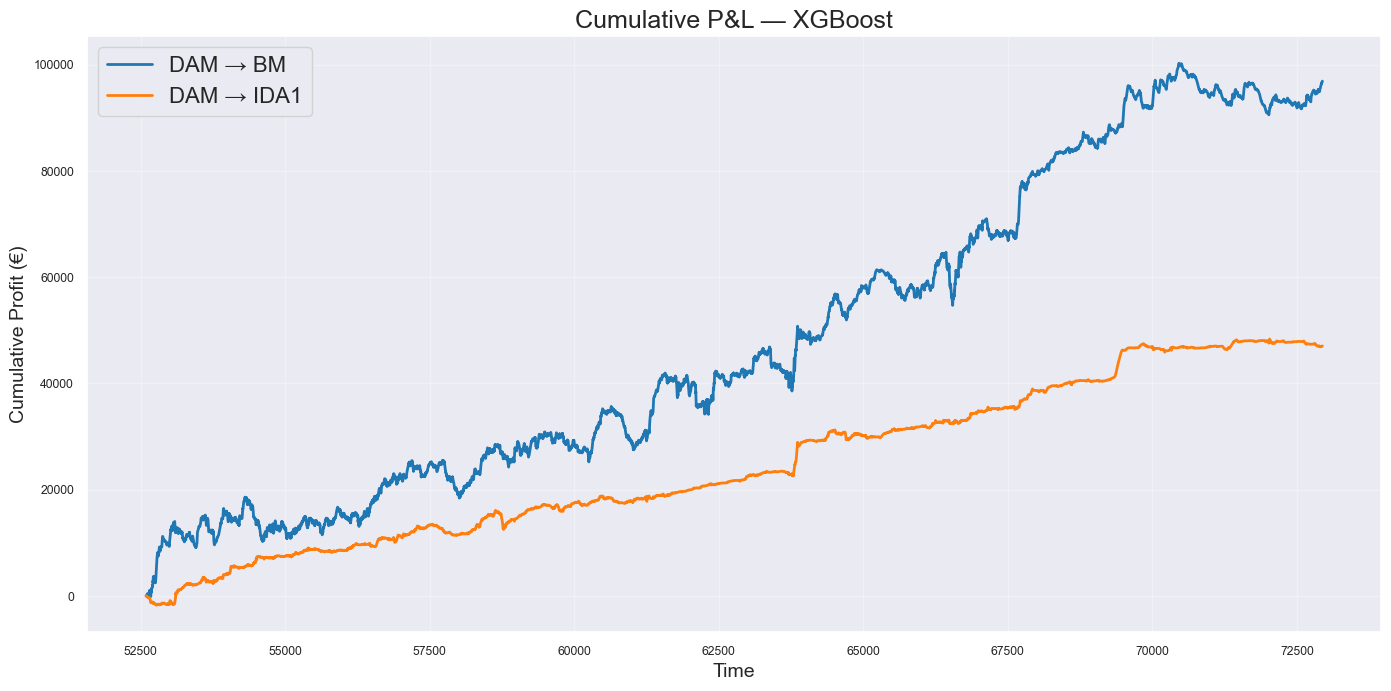

In [24]:
#Quintin Quinn Section
##Comparision Graphs 
logit_pnl = pd.Series(raw_logit_dir, index=test.index) * test["spread"]
rf_pnl    = pd.Series(raw_rf_dir,    index=test.index) * test["spread"]
xgb_pnl   = pd.Series(raw_xgb_dir,   index=test.index) * test["spread"]

# Cumulative P&L
cum_logit = logit_pnl.cumsum()
cum_rf    = rf_pnl.cumsum()
cum_xgb   = xgb_pnl.cumsum()

# Convert to Series to ensure alignment and indexing
logit_pnl_ida = pd.Series(raw_logit_dir_ida, index=test_ida.index) * test_ida["spread_ida"]
rf_pnl_ida    = pd.Series(raw_rf_dir_ida,    index=test_ida.index) * test_ida["spread_ida"]
xgb_pnl_ida   = pd.Series(raw_xgb_dir_ida,   index=test_ida.index) * test_ida["spread_ida"]

# Cumulative sums
cum_logit_ida = logit_pnl_ida.cumsum()
cum_rf_ida    = rf_pnl_ida.cumsum()
cum_xgb_ida   = xgb_pnl_ida.cumsum()



# LOGISTIC REGRESSION
plt.figure(figsize=(14,7))
plt.plot(cum_logit,     label="DAM → BM",   linewidth=2, color="#1f77b4")  # dark blue
plt.plot(cum_logit_ida, label="DAM → IDA1", linewidth=2, color="#ff7f0e")  # orange

plt.title("Cumulative P&L — Logistic Regression", fontsize=18)
plt.xlabel("Time", fontsize=14)
plt.ylabel("Cumulative Profit (€)", fontsize=14)
plt.grid(True, alpha=0.3)
plt.legend(fontsize=16)   # BIGGER LEGEND
plt.tight_layout()
plt.show()


# RANDOM FOREST
plt.figure(figsize=(14,7))
plt.plot(cum_rf,     label="DAM → BM",   linewidth=2, color="#1f77b4")  # dark blue
plt.plot(cum_rf_ida, label="DAM → IDA1", linewidth=2, color="#ff7f0e")  # orange

plt.title("Cumulative P&L — Random Forest", fontsize=18)
plt.xlabel("Time", fontsize=14)
plt.ylabel("Cumulative Profit (€)", fontsize=14)
plt.grid(True, alpha=0.3)
plt.legend(fontsize=16)
plt.tight_layout()
plt.show()


# XGBOOST
plt.figure(figsize=(14,7))
plt.plot(cum_xgb,     label="DAM → BM",   linewidth=2, color="#1f77b4")  # dark blue
plt.plot(cum_xgb_ida, label="DAM → IDA1", linewidth=2, color="#ff7f0e")  # orange

plt.title("Cumulative P&L — XGBoost", fontsize=18)
plt.xlabel("Time", fontsize=14)
plt.ylabel("Cumulative Profit (€)", fontsize=14)
plt.grid(True, alpha=0.3)
plt.legend(fontsize=16)
plt.tight_layout()
plt.show()

In [25]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)


In [26]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

# Logistic Regression 
logit = LogisticRegression(
    max_iter=1000,
    class_weight="balanced",
    random_state=42
)
logit.fit(X_train_scaled, y_train)

# Random Forest 
rf = RandomForestClassifier(
    n_estimators=300,
    max_depth=8,
    min_samples_leaf=50,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)
rf.fit(X_train, y_train)

# XGBoost 
y_train_xgb = (y_train == 1).astype(int)


#####
pos_weight = (y_train_xgb == 0).sum() / (y_train_xgb == 1).sum() 
print("scale_pos_weight =", pos_weight)

xgb = XGBClassifier(
    n_estimators=300,
    max_depth=5,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="binary:logistic",
    eval_metric="logloss",
    scale_pos_weight=pos_weight,   # <-- NEW
    random_state=42
)

xgb.fit(X_train, y_train_xgb)


scale_pos_weight = 1.1989872782055575


XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.8, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.05, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=5, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=300, n_jobs=None,
              num_parallel_tree=None, ...)

In [27]:
# Logistic Regression
logit_test_prob = logit.predict_proba(X_test_scaled)[:,1]

# Random Forest
rf_test_prob = rf.predict_proba(X_test)[:,1]

# XGBoost
xgb_test_prob = xgb.predict_proba(X_test)[:,1]



In [28]:
# --- TRAIN probabilities (needed for Option C) ---
logit_train_prob = logit.predict_proba(X_train_scaled)[:, 1]
rf_train_prob    = rf.predict_proba(X_train)[:, 1]
xgb_train_prob   = xgb.predict_proba(X_train)[:, 1]





In [29]:
def evaluate_exec_trades(model_name, exec_dir, y_true, spread):
    """
    Evaluate only the executed trades (exec_dir != 0).
    """
    mask = exec_dir != 0
    
    y_pred = exec_dir[mask]
    y_t = y_true.loc[mask] if hasattr(y_true, "loc") else y_true[mask]
    sp = spread.loc[mask] if hasattr(spread, "loc") else spread[mask]

    pnl = y_pred * sp
    print(f"\n===== {model_name} (Top {int(TRADE_RATE*100)}% confidence) =====")
    print("Trades:", int(mask.sum()))
    print("Total P&L:", round(pnl.sum(), 2))
    print("€/MWh:", round(pnl.sum() / mask.sum(), 3))
    print("Win rate:", round((pnl > 0).mean(), 3))
    
    if (pnl < 0).any():
        pf = pnl[pnl > 0].sum() / abs(pnl[pnl < 0].sum())
    else:
        pf = float("inf")
    print("Profit factor:", round(pf, 3))


In [30]:
def trade_top_confidence(prob_train, prob_test, trade_rate=0.20):

    conf_train = np.maximum(prob_train, 1 - prob_train)
    cutoff = np.quantile(conf_train, 1 - trade_rate)

    conf_test = np.maximum(prob_test, 1 - prob_test)
    direction_test = np.where(prob_test >= 0.5, 1, -1)
    exec_dir_test = direction_test * (conf_test >= cutoff)

    return exec_dir_test, cutoff


# Decide this BEFORE seeing test results (pre-registered)
TRADE_RATE = 0.015# e.g. trade top 5% most confident signals

# Logistic
exec_logit, cutoff_logit = trade_top_confidence(logit_train_prob, logit_test_prob, trade_rate=TRADE_RATE)

# RF
exec_rf, cutoff_rf = trade_top_confidence(rf_train_prob, rf_test_prob, trade_rate=TRADE_RATE)

# XGB
exec_xgb, cutoff_xgb = trade_top_confidence(xgb_train_prob, xgb_test_prob, trade_rate=TRADE_RATE)

print("Confidence cutoffs (from TRAIN only):")
print("Logit cutoff:", round(cutoff_logit, 4))
print("RF cutoff:", round(cutoff_rf, 4))
print("XGB cutoff:", round(cutoff_xgb, 4))


Confidence cutoffs (from TRAIN only):
Logit cutoff: 0.7525
RF cutoff: 0.7445
XGB cutoff: 0.8687


In [31]:
evaluate_exec_trades("Logit", exec_logit, y_test, test["spread"])
evaluate_exec_trades("XGB", exec_xgb, y_test, test["spread"])


evaluate_exec_trades("RF", exec_rf, y_test, test["spread"])



===== Logit (Top 1% confidence) =====
Trades: 395
Total P&L: 15783.11
€/MWh: 39.957
Win rate: 0.684
Profit factor: 2.71

===== XGB (Top 1% confidence) =====
Trades: 258
Total P&L: 3153.19
€/MWh: 12.222
Win rate: 0.764
Profit factor: 3.962

===== RF (Top 1% confidence) =====
Trades: 363
Total P&L: -707.35
€/MWh: -1.949
Win rate: 0.741
Profit factor: 0.83


In [32]:
#Quintin Quinn Section
from sklearn.metrics import accuracy_score

# Convert probabilities → predicted class (1 or -1)
logit_pred = np.where(logit_test_prob >= 0.5, 1, -1)
rf_pred    = np.where(rf_test_prob    >= 0.5, 1, -1)
xgb_pred   = np.where(xgb_test_prob   >= 0.5, 1, -1)

# Compute accuracy
acc_logit = accuracy_score(y_test, logit_pred)
acc_rf    = accuracy_score(y_test, rf_pred)
acc_xgb   = accuracy_score(y_test, xgb_pred)

print("Model Accuracies:")
print("Logit:", round(acc_logit, 4))
print("RF:",    round(acc_rf, 4))
print("XGB:",   round(acc_xgb, 4))


Model Accuracies:
Logit: 0.5488
RF: 0.5548
XGB: 0.5569


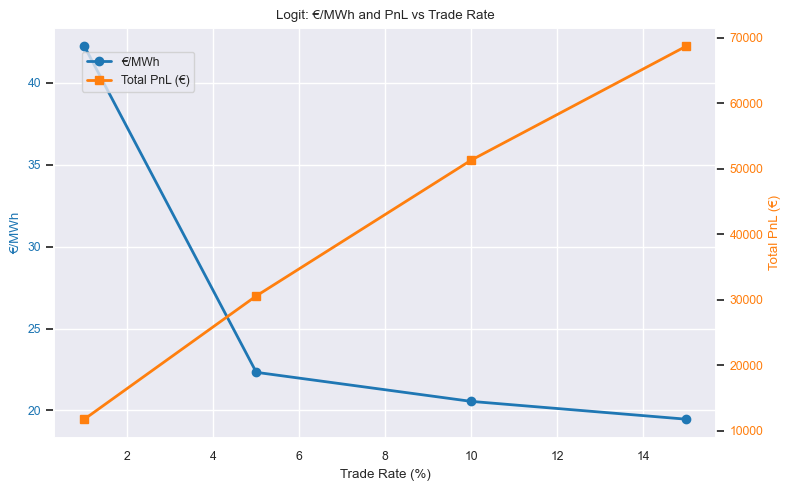

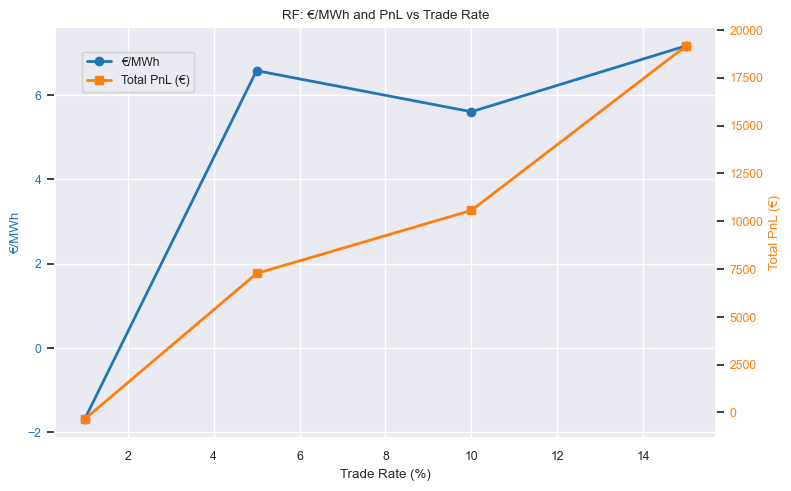

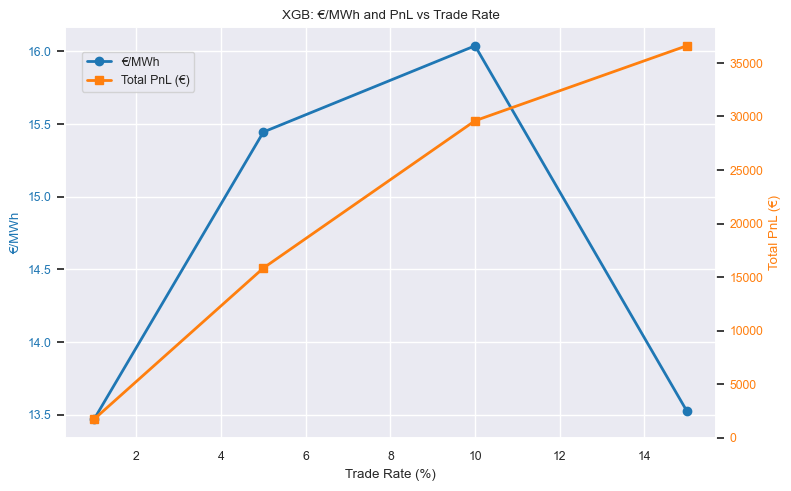

In [33]:
#Quintin Quinn Section

spreads = df.loc[df["StartDateTime"] >= "2025-01-01", "spread"].values

def trade_top_confidence(prob_train, prob_test, trade_rate):
    conf_train = np.maximum(prob_train, 1 - prob_train)
    cutoff = np.quantile(conf_train, 1 - trade_rate)

    conf_test = np.maximum(prob_test, 1 - prob_test)
    direction_test = np.where(prob_test >= 0.5, 1, -1)
    exec_dir_test = direction_test * (conf_test >= cutoff)

    return exec_dir_test, cutoff

trade_rates = [0.01, 0.05, 0.10, 0.15]
trade_rates_pct = [r * 100 for r in trade_rates]

models = {
    "Logit": (logit_train_prob, logit_test_prob),
    "RF":    (rf_train_prob, rf_test_prob),
    "XGB":   (xgb_train_prob, xgb_test_prob),
}

results = {m: {"pnl": [], "eumwh": []} for m in models}

# Compute metrics
for model_name, (train_prob, test_prob) in models.items():
    for tr in trade_rates:
        exec_dir, cutoff = trade_top_confidence(train_prob, test_prob, tr)

        mask = exec_dir != 0
        pnl = exec_dir[mask] * spreads[mask]

        total_pnl = pnl.sum()
        eumwh = total_pnl / mask.sum()

        results[model_name]["pnl"].append(total_pnl)
        results[model_name]["eumwh"].append(eumwh)


# Plot: one figure per model with twin y-axes

for model_name in models:
    fig, ax1 = plt.subplots(figsize=(8, 5))

    # €/MWh on left y-axis
    line1 = ax1.plot(
        trade_rates_pct,
        results[model_name]["eumwh"],
        marker="o",
        color="tab:blue",
        label="€/MWh",
        linewidth=2,
    )
    ax1.set_xlabel("Trade Rate (%)")
    ax1.set_ylabel("€/MWh", color="tab:blue")
    ax1.tick_params(axis="y", labelcolor="tab:blue")

    # PnL on right y-axis
    ax2 = ax1.twinx()
    line2 = ax2.plot(
        trade_rates_pct,
        results[model_name]["pnl"],
        marker="s",
        color="tab:orange",
        label="Total PnL (€)",
        linewidth=2,
    )
    ax2.set_ylabel("Total PnL (€)", color="tab:orange")
    ax2.tick_params(axis="y", labelcolor="tab:orange")
    ax2.grid(False)

    # Combine legends
    lines = line1 + line2
    labels = [l.get_label() for l in lines]
    fig.legend(lines, labels, loc="upper left", bbox_to_anchor=(0.1, 0.9))
    
    plt.title(f"{model_name}: €/MWh and PnL vs Trade Rate")
    plt.savefig(f'example{model_name}.png')
    fig.tight_layout()
    plt.show()
   


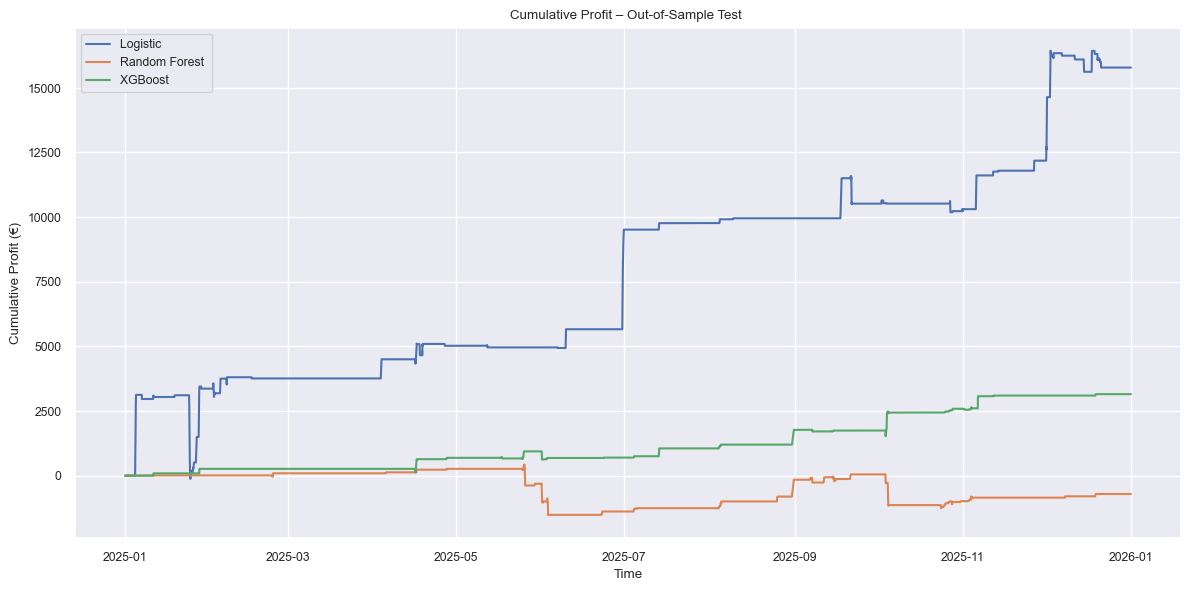

In [34]:
#Patrick Martin Section
# Cumulative P&L 


bt = test.copy()
bt["StartDateTime"] = pd.to_datetime(bt["StartDateTime"])
bt = bt.sort_values("StartDateTime")

bt["pnl_logit"] = exec_logit * bt["spread"]
bt["pnl_rf"]    = exec_rf * bt["spread"]
bt["pnl_xgb"]   = exec_xgb * bt["spread"]

bt["cum_logit"] = bt["pnl_logit"].cumsum()
bt["cum_rf"]    = bt["pnl_rf"].cumsum()
bt["cum_xgb"]   = bt["pnl_xgb"].cumsum()

plt.figure(figsize=(12, 6))

plt.plot(bt["StartDateTime"], bt["cum_logit"], label="Logistic ")
plt.plot(bt["StartDateTime"], bt["cum_rf"],    label="Random Forest ")
plt.plot(bt["StartDateTime"], bt["cum_xgb"],   label="XGBoost ")

plt.title("Cumulative Profit – Out-of-Sample Test ")
plt.xlabel("Time")
plt.ylabel("Cumulative Profit (€)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


In [35]:

#patrick martin section
def max_drawdown(cum_pnl: np.ndarray) -> float:
    """
    Max drawdown from a cumulative P&L series.
    Returns the most negative drawdown value (in €).
    """
    cum_pnl = np.asarray(cum_pnl, dtype=float)
    running_peak = np.maximum.accumulate(cum_pnl)
    drawdown = cum_pnl - running_peak
    return drawdown.min()  # negative number (e.g., -4500.0)



In [36]:
# Ensure time order
bt = test.copy()
bt["StartDateTime"] = pd.to_datetime(bt["StartDateTime"])
bt = bt.sort_values("StartDateTime")

# P&L per period (0 when no trade)
bt["pnl_logit"] = exec_logit * bt["spread"]
bt["pnl_rf"]    = exec_rf    * bt["spread"]
bt["pnl_xgb"]   = exec_xgb   * bt["spread"]

# Cumulative P&L
bt["cum_logit"] = bt["pnl_logit"].cumsum()
bt["cum_rf"]    = bt["pnl_rf"].cumsum()
bt["cum_xgb"]   = bt["pnl_xgb"].cumsum()

# Max drawdown (in €)
mdd_logit = max_drawdown(bt["cum_logit"].values)
mdd_rf    = max_drawdown(bt["cum_rf"].values)
mdd_xgb   = max_drawdown(bt["cum_xgb"].values)

print("Max Drawdown (€):")
print("Logit:", round(mdd_logit, 2))
print("XGB  :", round(mdd_xgb, 2))
print("RF   :", round(mdd_rf, 2))

Max Drawdown (€):
Logit: -3248.01
XGB  : -315.88
RF   : -1946.69


In [37]:


df["wind_uncertainty_DAM"] = df["ISEMWINDP90_DAM"] - df["ISEMWINDP10_DAM"]
############
df["wind_q"] = pd.qcut(
    df["wind_uncertainty_DAM"],
    q=4,
    labels=["Low", "Med-Low", "Med-High", "High"]
)
##########
train_wind = df[df["StartDateTime"] < "2025-01-01"].copy()
test_wind  = df[df["StartDateTime"] >= "2025-01-01"].copy()



# --- Create executed trades on TRAIN (Option C, same rule as test) ---
conf_train = np.maximum(logit_train_prob, 1 - logit_train_prob)
cutoff = np.quantile(conf_train, 1 - TRADE_RATE)

direction_train = np.where(logit_train_prob >= 0.5, 1, -1)
exec_logit_train = direction_train * (conf_train >= cutoff)


In [38]:
#Quintin Quinn Section

tmp = test_wind.copy()
tmp["exec_dir"] = exec_logit
tmp["pnl"] = tmp["exec_dir"] * tmp["spread"]
tmp["traded"] = tmp["exec_dir"] != 0

quartile_perf_test = (
    tmp[tmp["traded"]]
    .groupby("wind_q")
    .apply(lambda g: pd.Series({
        "trades": len(g),
        "eur_per_mwh": g["pnl"].sum() / len(g)
    }))
)


quartile_perf_test



C:\Users\40337868\AppData\Local\Temp\ipykernel_5492\1878699668.py:10: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby("wind_q")
C:\Users\40337868\AppData\Local\Temp\ipykernel_5492\1878699668.py:11: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: pd.Series({


,trades,eur_per_mwh
wind_q,,
Low,1.0,-14.770000
Med-Low,22.0,-12.356364
Med-High,71.0,-32.892254
High,301.0,61.146412


In [39]:
#Quintin Quinn Section
#########from the top 4% only allow trades that are in high uncertainty 
def trade_top_confidence(prob_train, prob_test, trade_rate=0.2):##############
    """
    Option C:
    - Choose a fixed trade rate (e.g. top 20% most confident)
    - Compute confidence cutoff on TRAIN only
    - Apply same cutoff on TEST
    Returns exec_dir (0, +1, -1) for test and the cutoff used.
    """
    conf_train = np.maximum(prob_train, 1 - prob_train)
    cutoff = np.quantile(conf_train, 1 - trade_rate)

    conf_test = np.maximum(prob_test, 1 - prob_test)
    direction_test = np.where(prob_test >= 0.5, 1, -1)
    exec_dir_test = direction_test * (conf_test >= cutoff)

    return exec_dir_test, cutoff


# Decide this BEFORE seeing test results (pre-registered)
TRADE_RATE = 0.01# e.g. trade top 5% most confident signals

# Logistic
exec_logit, cutoff_logit = trade_top_confidence(logit_train_prob, logit_test_prob, trade_rate=TRADE_RATE)

# RF
exec_rf, cutoff_rf = trade_top_confidence(rf_train_prob, rf_test_prob, trade_rate=TRADE_RATE)

# XGB
exec_xgb, cutoff_xgb = trade_top_confidence(xgb_train_prob, xgb_test_prob, trade_rate=TRADE_RATE)

exec_logit_high_only = exec_logit.copy() 
exec_logit_high_only[test_wind["wind_q"] != "High"] = 0

print("Confidence cutoffs (from TRAIN only):")
print("Logit cutoff:", round(cutoff_logit, 4))
print("RF cutoff:", round(cutoff_rf, 4))
print("XGB cutoff:", round(cutoff_xgb, 4))


Confidence cutoffs (from TRAIN only):
Logit cutoff: 0.7766
RF cutoff: 0.77
XGB cutoff: 0.8995


In [40]:
evaluate_exec_trades("Baseline Logit (High-uncertainty only)", 
                     exec_logit_high_only, 
                     y_test, 
                     test_wind["spread"])


===== Baseline Logit (High-uncertainty only) (Top 1% confidence) =====
Trades: 214
Total P&L: 15272.29
€/MWh: 71.366
Win rate: 0.79
Profit factor: 7.557


In [41]:


# Only evaluate accuracy on the hours where the model actually traded
mask = exec_logit_high_only != 0

if mask.sum() == 0:
    print("No trades executed, accuracy undefined.")
else:
    accuracy = accuracy_score(y_test[mask], exec_logit_high_only[mask])
    print("Model accuracy:", round(accuracy, 4))


Model accuracy: 0.7897


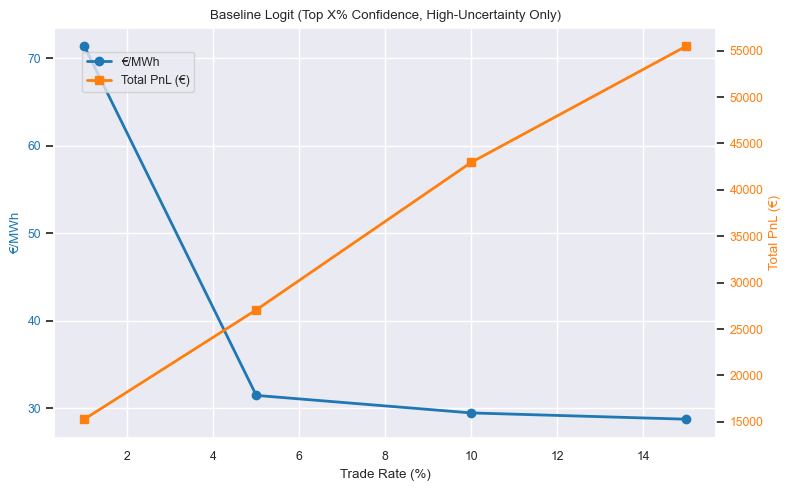

In [42]:
#Quintin Quinn Section

# Baseline model: top X% confidence, but only inside High uncertainty


trade_rates = [0.01, 0.05, 0.10, 0.15]
trade_rates_pct = [r * 100 for r in trade_rates]

results_high_filtered = {"pnl": [], "eumwh": []}

# Precompute spreads
spreads = test_wind["spread"].values

# High-uncertainty mask
high_mask = (test_wind["wind_q"] == "High")

for tr in trade_rates:
    # Baseline top-X% confidence trades
    exec_dir, cutoff = trade_top_confidence(logit_train_prob, logit_test_prob, tr)

    # Filter to High-uncertainty only
    exec_dir_high = exec_dir.copy()
    exec_dir_high[~high_mask] = 0

    # Compute PnL
    mask = exec_dir_high != 0
    pnl = exec_dir_high[mask] * spreads[mask]

    total_pnl = pnl.sum()
    eumwh = total_pnl / mask.sum() if mask.sum() > 0 else 0

    results_high_filtered["pnl"].append(total_pnl)
    results_high_filtered["eumwh"].append(eumwh)


# Plot: €/MWh and PnL vs Trade Rate

fig, ax1 = plt.subplots(figsize=(8, 5))

# €/MWh on left y-axis
line1 = ax1.plot(
    trade_rates_pct,
    results_high_filtered["eumwh"],
    marker="o",
    color="tab:blue",
    label="€/MWh",
    linewidth=2,
)
ax1.set_xlabel("Trade Rate (%)")
ax1.set_ylabel("€/MWh", color="tab:blue")
ax1.tick_params(axis="y", labelcolor="tab:blue")

# PnL on right y-axis
ax2 = ax1.twinx()
line2 = ax2.plot(
    trade_rates_pct,
    results_high_filtered["pnl"],
    marker="s",
    color="tab:orange",
    label="Total PnL (€)",
    linewidth=2,
)
ax2.set_ylabel("Total PnL (€)", color="tab:orange")
ax2.tick_params(axis="y", labelcolor="tab:orange")
ax2.grid(False)

# Combine legends
lines = line1 + line2
labels = [l.get_label() for l in lines]
fig.legend(lines, labels, loc="upper left", bbox_to_anchor=(0.1, 0.9))

plt.title("Baseline Logit (Top X% Confidence, High-Uncertainty Only)")
fig.tight_layout()
plt.show()


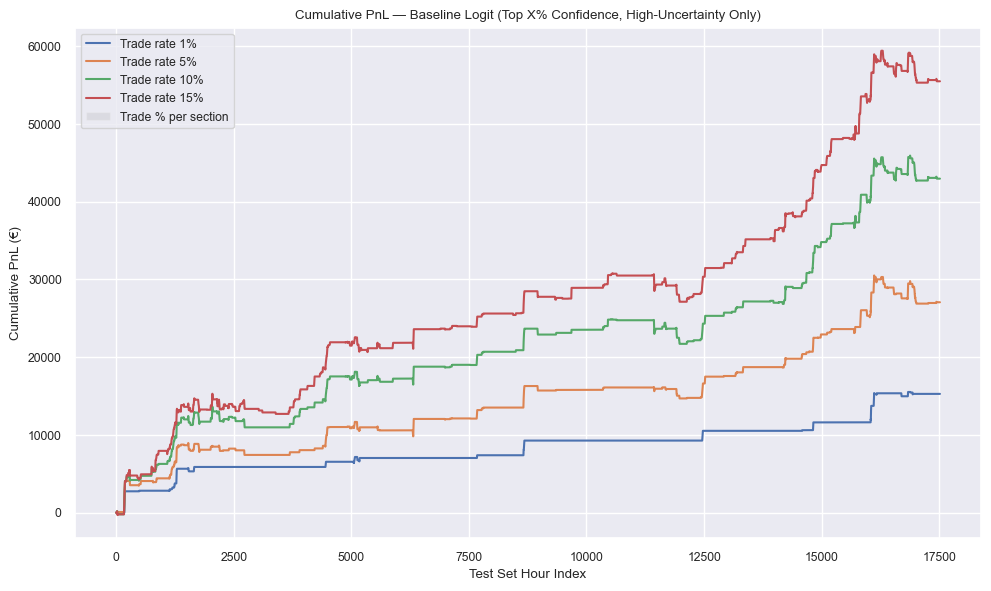

In [43]:
#Quintin Quinn Section

fig, ax = plt.subplots(figsize=(10, 6))

# ============================================================
# 1. Plot cumulative PnL lines (your existing code)
# ============================================================
for tr in trade_rates:
    exec_dir, cutoff = trade_top_confidence(logit_train_prob, logit_test_prob, tr)

    exec_dir_high = exec_dir.copy()
    exec_dir_high[~high_mask] = 0

    pnl_per_hour = exec_dir_high * spreads
    cum_pnl = np.cumsum(pnl_per_hour)

    ax.plot(cum_pnl, label=f"Trade rate {int(tr*100)}%")

# ============================================================
# 2. Compute trade counts per section (5 equal bins)
# ============================================================
n = len(exec_dir_high)
section_edges = np.linspace(0, n, 6, dtype=int)  # 5 sections → 6 edges

trade_counts = []
for i in range(5):
    start, end = section_edges[i], section_edges[i+1]
    trades_in_section = np.sum(exec_dir_high[start:end] != 0)
    trade_counts.append(trades_in_section)

# Normalize to percentage of total trades
total_trades = sum(trade_counts)
trade_percent = [tc / total_trades for tc in trade_counts]

# ============================================================
# 3. Add transparent bars behind the PnL lines
# ============================================================
bar_width = n / 5

for i, pct in enumerate(trade_percent):
    ax.bar(
        i * bar_width + bar_width/2,
        pct,
        width=bar_width,
        alpha=0.15,
        color="gray",
        align="center",
        zorder=0,
        label="Trade % per section" if i == 0 else None
    )

# ============================================================
# 4. Final formatting
# ============================================================
ax.set_title("Cumulative PnL — Baseline Logit (Top X% Confidence, High-Uncertainty Only)")
ax.set_xlabel("Test Set Hour Index")
ax.set_ylabel("Cumulative PnL (€)")
ax.legend()
ax.grid(True)

plt.tight_layout()
plt.show()


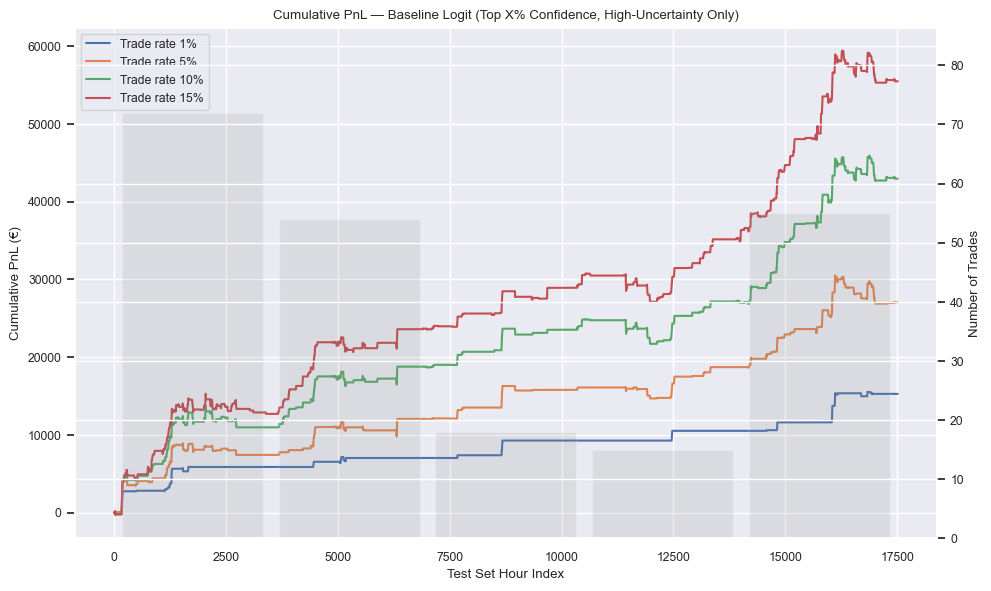


=== Max Drawdowns for Each Trade Rate ===
Trade rate 1% → Max Drawdown: -570.67 €
Trade rate 5% → Max Drawdown: -3620.35 €
Trade rate 10% → Max Drawdown: -3265.48 €
Trade rate 15% → Max Drawdown: -4104.12 €


In [44]:

# Max Drawdown  function
def max_drawdown(cum_pnl):
    running_max = np.maximum.accumulate(cum_pnl)
    drawdowns = cum_pnl - running_max
    return drawdowns.min()   # most negative drop


# Main Plotting Section
fig, ax1 = plt.subplots(figsize=(10, 6))

max_dds = {}  # store max drawdowns for each trade rate

# 1. Plot cumulative PnL lines 
for tr in trade_rates:
    exec_dir, cutoff = trade_top_confidence(logit_train_prob, logit_test_prob, tr)

    exec_dir_high = exec_dir.copy()
    exec_dir_high[~high_mask] = 0

    pnl_per_hour = exec_dir_high * spreads
    cum_pnl = np.cumsum(pnl_per_hour)

    # ---- store max drawdown ----
    max_dds[tr] = max_drawdown(cum_pnl)

    ax1.plot(cum_pnl, label=f"Trade rate {int(tr*100)}%")


# 2. Choose which threshold the bars represent
bar_trade_rate = 0.01  # choose the threshold 

exec_bar, _ = trade_top_confidence(logit_train_prob, logit_test_prob, bar_trade_rate)
exec_bar_high = exec_bar.copy()
exec_bar_high[~high_mask] = 0

# 3. Compute trade counts in 5 equal sections
n = len(exec_bar_high)
section_edges = np.linspace(0, n, 6, dtype=int)

trade_counts = []
for i in range(5):
    start, end = section_edges[i], section_edges[i+1]
    trade_counts.append(np.sum(exec_bar_high[start:end] != 0))

# x‑positions for bars 
x_centers = [(section_edges[i] + section_edges[i+1]) / 2 for i in range(5)]
bar_width = (n / 5) * 0.9

# 4. Plot bars on a secondary y-axis 
ax2 = ax1.twinx()

ax2.bar(
    x_centers,
    trade_counts,
    width=bar_width,
    alpha=0.15,
    color="gray",
    label=f"Trades (Top {int(bar_trade_rate*100)}%)",
    zorder=0
)

ax2.set_ylabel("Number of Trades")
ax2.set_ylim(0, max(trade_counts) * 1.2)

# 5. Final formatting
ax1.set_title("Cumulative PnL — Baseline Logit (Top X% Confidence, High-Uncertainty Only)")
ax1.set_xlabel("Test Set Hour Index")
ax1.set_ylabel("Cumulative PnL (€)")
ax1.legend(loc="upper left")
ax1.grid(True)

plt.tight_layout()
plt.show()

# 6. Print Max Drawdowns
print("\n=== Max Drawdowns for Each Trade Rate ===")
for tr, dd in max_dds.items():
    print(f"Trade rate {int(tr*100)}% → Max Drawdown: {dd:.2f} €")


In [45]:

trade_rates = [0.01, 0.05, 0.10, 0.15]

quartile_trade_counts = {}

for tr in trade_rates:
    # Get execution direction for this trade rate
    exec_dir, _ = trade_top_confidence(logit_train_prob, logit_test_prob, tr)

    # Apply high-uncertainty mask
    exec_dir_high = exec_dir.copy()
    exec_dir_high[~high_mask] = 0

    n = len(exec_dir_high)

    # Quartile boundaries
    edges = np.linspace(0, n, 5, dtype=int)

    counts = []
    for i in range(4):
        start, end = edges[i], edges[i+1]
        counts.append(np.sum(exec_dir_high[start:end] != 0))

    quartile_trade_counts[tr] = counts

# Print results
print("\n=== Trades per Quartile ===")
for tr, counts in quartile_trade_counts.items():
    print(f"Trade rate {int(tr*100)}% → Q1:{counts[0]}, Q2:{counts[1]}, Q3:{counts[2]}, Q4:{counts[3]}")



=== Trades per Quartile ===
Trade rate 1% → Q1:72, Q2:72, Q3:15, Q4:55
Trade rate 5% → Q1:259, Q2:190, Q3:84, Q4:327
Trade rate 10% → Q1:469, Q2:281, Q3:176, Q4:532
Trade rate 15% → Q1:644, Q2:356, Q3:232, Q4:698


In [46]:
###this code is not used at all. just for experimenting

In [47]:
#Quintin Quinn Section

# 1. Select High-uncertainty training subset

spread = test_wind["spread"]


train_high = train_wind[train_wind["wind_q"] == "High"].copy()
train_high = train_high.dropna(subset=dam_features)

X_train_high = train_high[dam_features].copy()
y_train_high = train_high["y_dir"]

# Scale
scaler_high = StandardScaler()
X_train_high_scaled = scaler_high.fit_transform(X_train_high)
X_test_scaled = scaler_high.transform(X_test)

# Fit the specialist model
logit_high = LogisticRegression(
    max_iter=1000,
    class_weight="balanced",
    random_state=42
)
logit_high.fit(X_train_high_scaled, y_train_high)

# NOW you can compute test probabilities
logit_high_test_prob = logit_high.predict_proba(X_test_scaled)[:,1]

TRADE_RATE_HIGH = 0.01  # or 0.05, 0.10, 0.15, etc.


#  Compute confidence and direction
conf_test = np.maximum(logit_high_test_prob, 1 - logit_high_test_prob)
direction_test = np.where(logit_high_test_prob >= 0.5, 1, -1)

# High-uncertainty mask
high_mask = (test_wind["wind_q"] == "High")

#  Compute cutoff ONLY inside High-uncertainty hours
conf_high = conf_test[high_mask]
cutoff_high_unc = np.quantile(conf_high, 1 - TRADE_RATE_HIGH)

# Execute trades ONLY inside High AND above cutoff
exec_logit_high_unc = np.zeros_like(direction_test)
exec_logit_high_unc[high_mask] = (
    direction_test[high_mask] * (conf_test[high_mask] >= cutoff_high_unc)
)

evaluate_exec_trades("Logit (High uncertainty + top X% confidence)",
                     exec_logit_high_unc,
                     y_test,
                     spread)




===== Logit (High uncertainty + top X% confidence) (Top 1% confidence) =====
Trades: 58
Total P&L: 3822.2
€/MWh: 65.9
Win rate: 0.879
Profit factor: 13.336


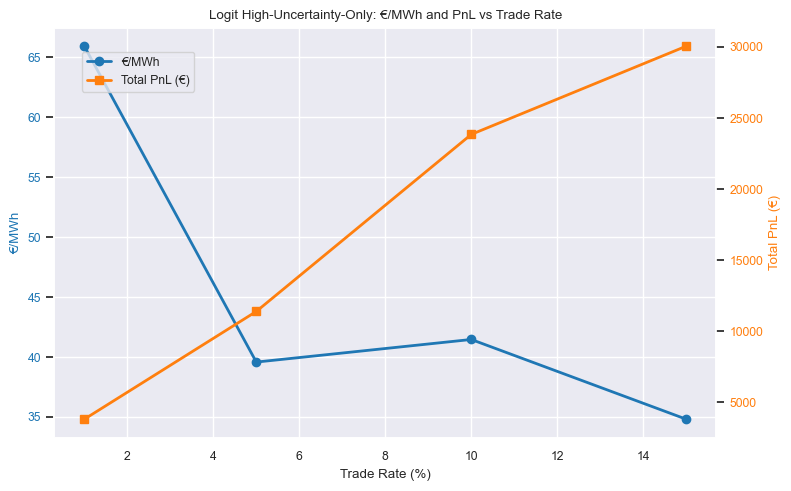

In [48]:
#Quintin Quinn Section

trade_rates_high = [0.01, 0.05, 0.10, 0.15]
trade_rates_high_pct = [r * 100 for r in trade_rates_high]

results_high = {"pnl": [], "eumwh": []}

# Precompute confidence + direction
conf_test = np.maximum(logit_high_test_prob, 1 - logit_high_test_prob)
direction_test = np.where(logit_high_test_prob >= 0.5, 1, -1)

# High-uncertainty mask
high_mask = (test_wind["wind_q"] == "High")

# Loop over different trade rates
for tr in trade_rates_high:
    
    # Compute cutoff only inside High-uncertainty hours
    conf_high = conf_test[high_mask]
    cutoff_high_unc = np.quantile(conf_high, 1 - tr)

    # Execute trades only inside High AND above cutoff
    exec_dir = np.zeros_like(direction_test)
    exec_dir[high_mask] = (
        direction_test[high_mask] * (conf_test[high_mask] >= cutoff_high_unc)
    )

    # Compute PnL
    mask = exec_dir != 0
    pnl = exec_dir[mask] * spread[mask]

    total_pnl = pnl.sum()
    eumwh = total_pnl / mask.sum() if mask.sum() > 0 else 0

    results_high["pnl"].append(total_pnl)
    results_high["eumwh"].append(eumwh)


# Plot: €/MWh and PnL vs Trade Rate
 
fig, ax1 = plt.subplots(figsize=(8, 5))

# €/MWh on left y-axis
line1 = ax1.plot(
    trade_rates_high_pct,
    results_high["eumwh"],
    marker="o",
    color="tab:blue",
    label="€/MWh",
    linewidth=2,
)
ax1.set_xlabel("Trade Rate (%)")
ax1.set_ylabel("€/MWh", color="tab:blue")
ax1.tick_params(axis="y", labelcolor="tab:blue")

# PnL on right y-axis
ax2 = ax1.twinx()
line2 = ax2.plot(
    trade_rates_high_pct,
    results_high["pnl"],
    marker="s",
    color="tab:orange",
    label="Total PnL (€)",
    linewidth=2,
)
ax2.set_ylabel("Total PnL (€)", color="tab:orange")
ax2.tick_params(axis="y", labelcolor="tab:orange")
ax2.grid(False)

# Combine legends
lines = line1 + line2
labels = [l.get_label() for l in lines]
fig.legend(lines, labels, loc="upper left", bbox_to_anchor=(0.1, 0.9))

plt.title("Logit High-Uncertainty-Only: €/MWh and PnL vs Trade Rate")
fig.tight_layout()
plt.show()
